<a href="https://colab.research.google.com/github/AliceFranca0/tcc-deteccao-fake-news-ptbr/blob/main/Fase3_Analise_Comparativa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 3 — Análise Comparativa por Categoria

Gera a análise de desempenho dos classificadores segmentada por categoria temática, produzindo a figura correspondente do artigo.

## 1. Ambiente

In [1]:
from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/TCC"

import os
os.makedirs(f"{BASE}/dados", exist_ok=True)
os.makedirs(f"{BASE}/figuras", exist_ok=True)
os.makedirs(f"{BASE}/modelos", exist_ok=True)

print("Pastas prontas em", BASE)

Mounted at /content/drive
Pastas prontas em /content/drive/MyDrive/TCC


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

CORAL = "#EF476F"   # Fake
AZUL = "#118AB2"    # Real

mpl.rcParams.update({
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlecolor": "#073B4C",
    "axes.labelsize": 10.5,
    "axes.labelweight": "bold",
    "axes.edgecolor": "#999999",
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#E6E6E6",
    "grid.linewidth": 0.7,
    "legend.frameon": False,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

In [3]:
import pandas as pd
import numpy as np

resultados = pd.read_csv(f"{BASE}/dados/resultados_classificacao.csv")
print(f"{len(resultados)} previsões carregadas")

2381 previsões carregadas


## 2. Acurácia por categoria

In [4]:
acuracia = resultados.groupby("categoria").agg(
    acuracia_lr=("acertou_lr", "mean"),
    acuracia_rf=("acertou_rf", "mean"),
    n=("acertou_lr", "size"),
).reset_index().sort_values("n", ascending=False)

acuracia.round(4)

,categoria,acuracia_lr,acuracia_rf,n
5,saúde,0.9602,0.9556,879
4,política,0.9209,0.9094,784
2,entretenimento,0.9707,0.9744,273
0,brasil,0.9430,0.9637,193
3,mundo,0.9281,0.9209,139
1,ciência,0.9292,0.8761,113


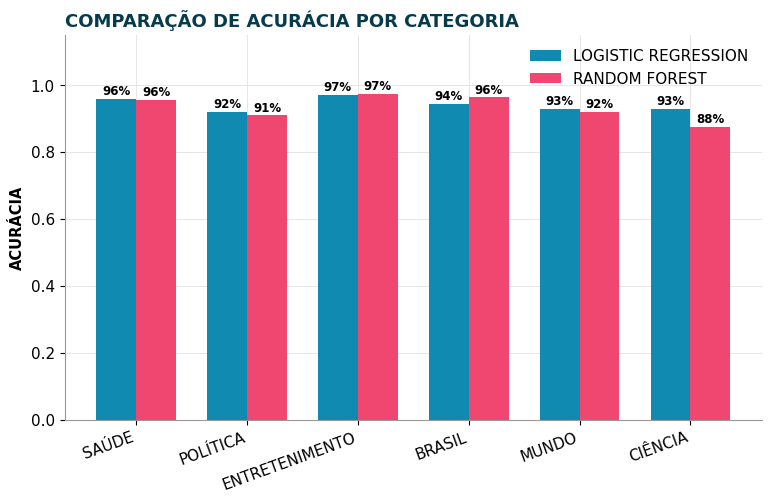

In [5]:
x = np.arange(len(acuracia))
largura = 0.36

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - largura/2, acuracia["acuracia_lr"], largura, label="LOGISTIC REGRESSION", color=AZUL)
b2 = ax.bar(x + largura/2, acuracia["acuracia_rf"], largura, label="RANDOM FOREST", color=CORAL)

for barras in [b1, b2]:
    for barra in barras:
        h = barra.get_height()
        ax.annotate(f"{h:.0%}", xy=(barra.get_x() + barra.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points", ha="center",
                    fontsize=8.5, fontweight="bold")

ax.set_ylabel("ACURÁCIA")
ax.set_title("COMPARAÇÃO DE ACURÁCIA POR CATEGORIA", loc="left")
ax.set_xticks(x)
ax.set_xticklabels([c.upper() for c in acuracia["categoria"]], rotation=20, ha="right")
ax.set_ylim(0, 1.15)
ax.legend()
plt.savefig(f"{BASE}/figuras/figura_acuracia_por_categoria.png")
plt.show()

## 3. Relação entre tamanho do texto e acerto

Verificação complementar do viés identificado na Fase 1: os erros dos modelos concentram-se em alguma faixa de tamanho de texto?

  n_palavras  acuracia_lr  acuracia_rf     n
0       0-50       0.9365       0.9492   551
1     51-100       0.9456       0.9374  1231
2    101-150       0.9475       0.9332   419
3    151-200       0.9333       0.8952   105
4       200+       0.9600       0.9333    75


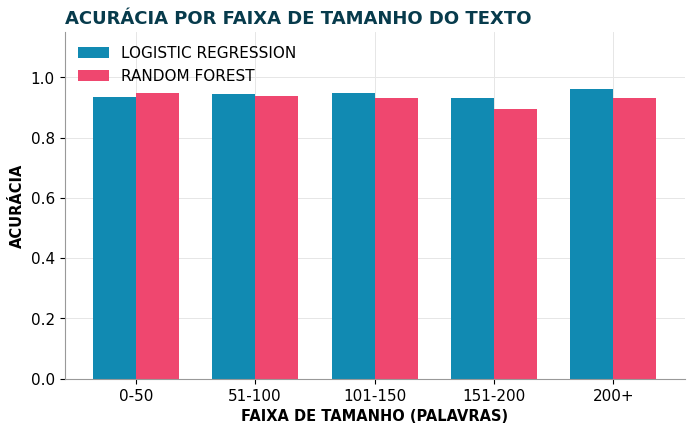

In [6]:
faixas = pd.cut(resultados["n_palavras"], bins=[0, 50, 100, 150, 200, 10000],
                labels=["0-50", "51-100", "101-150", "151-200", "200+"])

analise = resultados.groupby(faixas, observed=True).agg(
    acuracia_lr=("acertou_lr", "mean"),
    acuracia_rf=("acertou_rf", "mean"),
    n=("acertou_lr", "size"),
).reset_index()

print(analise.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(analise))
ax.bar(x - 0.18, analise["acuracia_lr"], 0.36, label="LOGISTIC REGRESSION", color=AZUL)
ax.bar(x + 0.18, analise["acuracia_rf"], 0.36, label="RANDOM FOREST", color=CORAL)
ax.set_xticks(x)
ax.set_xticklabels(analise["n_palavras"].astype(str))
ax.set_xlabel("FAIXA DE TAMANHO (PALAVRAS)")
ax.set_ylabel("ACURÁCIA")
ax.set_title("ACURÁCIA POR FAIXA DE TAMANHO DO TEXTO", loc="left")
ax.set_ylim(0, 1.15)
ax.legend()
plt.savefig(f"{BASE}/figuras/acuracia_por_tamanho.png")
plt.show()

Esta análise é nova em relação à versão anterior do projeto e alimenta diretamente a discussão sobre *shortcut learning*: se a acurácia variar de forma acentuada entre as faixas, é indício adicional de que o tamanho do texto opera como atalho estatístico.